## CNN project for predicting turn direction from superior colliculus neural activity
- The superior colliculus (SC) is a midbrain region that encodes turn direction. Can we predict turn direction from SC spiking activity using a CNN?
- Data: Bilateral recording from mouse SC during a Y-maze navigation task (75 total neurons). Treat matrices of SC spiking data (neurons x time) as 'images' with labels of right or left turns
- Goal: Build CNNs to classify the images as right or left turns. Compare pure CNN and Hybrid CNN-Fully Connected models

### Load and format data to Pytorch Dataset

In [1]:
import torch
import pickle
import numpy as np
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

# toggle to use GPU
use_gpu = 0

# set device
if torch.backends.mps.is_available() and use_gpu == 1:
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CPU


In [2]:
# load SC data dict, [trials x neurons x time] for 'right' and 'left' turns
data_tmp = pickle.load(open('/Users/cameronwilhite/Downloads/right_left_dict.pkl', 'rb'))
print('right turns: ' + str(np.shape(data_tmp['right'])))
print('left turns: ' + str(np.shape(data_tmp['left'])))

# reformat: label = 1 for right turn, 0 for left turn
labels = np.concatenate((
    np.ones(len(data_tmp['right']), dtype=np.int16),
    np.zeros(len(data_tmp['left']), dtype=np.int16)
))
activities = np.concatenate((data_tmp['right'], data_tmp['left']))
activities = np.expand_dims(activities, 1)  # add channel dimension

data = {
    'labels': labels,
    'activities': activities
}

right turns: (237, 75, 79)
left turns: (243, 75, 79)


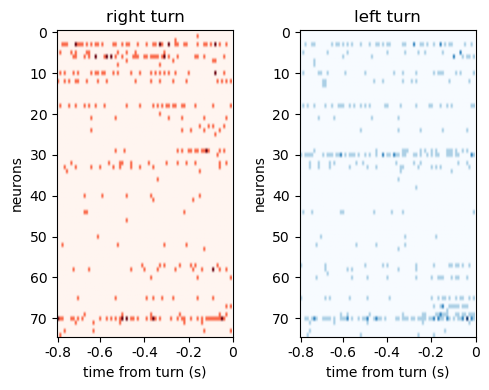

In [3]:
# plot example data from a right and a left trial (i.e., two example 'images')
plt.figure(figsize=(5,4))

plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(data['activities'][103]), aspect='auto', cmap='Reds')
plt.xticks([0,19,39,59,79], labels = [-0.8, -0.6, -0.4, -0.2, 0])
plt.xlabel('time from turn (s)')
plt.ylabel('neurons')
plt.title('right turn')

plt.subplot(1, 2, 2)
plt.imshow(np.squeeze(data['activities'][277]), aspect='auto', cmap='Blues')
plt.xticks([0,19,39,59,79], labels = [-0.8, -0.6, -0.4, -0.2, 0])
plt.xlabel('time from turn (s)')
plt.ylabel('neurons')
plt.title('left turn')

plt.tight_layout()

In [4]:
#create custom dataset
class CustomDataset(Dataset):
      # - activity: [channels x neurons x time] array (treated like an image)
      # - label: 1 = right turn, 0 = left turn
    def __init__(self, data, transform=None, target_transform=None):
        self.labels = data['labels']
        self.activities = data['activities']
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        activity = self.activities[idx]
        label = self.labels[idx]
        if self.transform:
            activity = self.transform(activity)
        if self.target_transform:
            label = self.target_transform(label)
        return activity, label
        
# initialize
dataset = CustomDataset(data)

### Functions for train-test split

In [5]:
from torch.utils.data import random_split, DataLoader

def train_test_split(dataset, train_ratio=0.8, batch_size=8):

    train_size = int(train_ratio * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size,
        shuffle=True)
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size,
        shuffle=False)
    return train_loader, test_loader

def train(model, 
          device, 
          train_loader, 
          optimizer,
          criterion,
          epoch,  # only needed for logging
          log_interval=10):
    
    model.train()  # sets the parameters to be trainable
    correct = 0

    for data, target in train_loader:

        data, target = data.to(device, dtype=torch.float), target.to(device, dtype=torch.float)
        
        optimizer.zero_grad()

        output = model(data)
        output = torch.squeeze(output)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        pred = output > 0.5
        correct += pred.eq(target.view_as(pred)).sum().item()  # tally the number of correct
    
    return loss.item()
        
def test(model, 
         device,
         criterion,
         test_loader):
    
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:

            data, target = data.to(device, dtype=torch.float), target.to(device, dtype=torch.float)
            
            output = model(data)
            output = torch.squeeze(output)
            test_loss += criterion(output, target).item()  # sum the batch loss
            pred = output > 0.5
            correct += pred.eq(target.view_as(pred)).sum().item()  # tally the number of correct

    test_loss /= len(test_loader.dataset)

    return 100. * correct / len(test_loader.dataset)

### Build pure CNN model
- Will try pure CNN first, even though the adjacency of neurons has no meaning in the activity matrix, so having small spatial convolution filters may not be desirable (see hybrid model below)

In [6]:
import torch.nn as nn
import torch.nn.functional as F
import math

n_neurons = np.shape(data_tmp['right'])[1]
print(str(n_neurons) + ' neurons')

class PureCNN(nn.Module):
    def __init__(self, nbins=1, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 8, kernel_size=(n_neurons, nbins), stride=stride)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=(1, 3), stride=1)
        self.conv3 = nn.Conv2d(16, 1, kernel_size=(1, 1))
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)  # shape: [batch, 1, 1, time_reduced]
        x = torch.mean(x, dim=[2, 3])  # global average pooling
        return self.sigmoid(x)  # shape: [batch, 1]

75 neurons


### Build hybrid CNN model
- The activity for each trial is represented by a 75x79 matrix (neurons x timepoints). There are only 384 training examples (80% of 480 total trials). A fully connected neural network will have ~6000 * n1 * n2 * ... weights to train, which may overfit and will be too taxing for the small training set. 
- Using a CovNet as the first layer, we can reduce the data size to 1 x 79/step values. The total number of weights to be trained will be: 75xt_win + 79/step * n1 * n2 * ..., which will be much more managable by the small dataset. 
- Adjacency of neurons has no meaning in the activity matrix, so this might be more straight forward

In [7]:
class HybridCNN(nn.Module):
    def __init__(self, nbins=1, nchannels=1, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, nchannels, kernel_size=(n_neurons, nbins), stride=stride) # n_neurons -> 1 x 79/kernel_size[1] * n
        self.n_conv1 = math.ceil((79-nbins+1)/stride) * nchannels
        self.fc1 = nn.Linear(self.n_conv1, 50) 
        self.fc2 = nn.Linear(50, 10)
        self.fc3 = nn.Linear(10, 1) 

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = x.view(-1,self.n_conv1) # unrolls for fully connected
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.sigmoid(x)

### Run model (Pure CNN)

In [8]:
criterion = nn.BCELoss()
epochs = 50
model_iters = 10 #(train-test splits)
loss_models = {}
test_score_models = {}

for model_to_run in ['pure']: #'pure', 'hybrid'
    loss_all = []
    test_scores = []

    # for nbins in np.arange(1,11): # test different time bins
    
    for nbins in [3]: # becomes stable with 3+ bins
        print('Training models with filter size ' + str(n_neurons) + 'x' + str(nbins))

        filters_all = []
        # how many iterations of the model to run
        for _ in range(0, model_iters):

            train_loader, test_loader = train_test_split(dataset)
            
            # initialize model based on type
            if model_to_run == 'pure':
                model = PureCNN(nbins=nbins)
                if use_gpu:
                    model = model.to(device)
            elif model_to_run == 'hybrid':
                model = HybridCNN(nbins=nbins)
                if use_gpu:
                    model = model.to(device)

            loss_epoch = []
            lr = 0.01

            for idx, epoch in enumerate(range(epochs)):
                if idx % 10 == 0 and idx < 30:
                    lr /= 10
                optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                loss = train(model, device, train_loader, optimizer, criterion, epoch)
                loss_epoch.append(loss)

            loss_all.append(loss_epoch)

            test_score = test(model, device, criterion, test_loader)
            test_scores.append(test_score)

            # extract filters for visualization
            filters = np.squeeze(model.conv1.weight.data.cpu().numpy())  # move to CPU and convert to numpy
            filters_all.append(filters)

    loss_models[model_to_run] = loss_all
    test_score_models[model_to_run] = test_scores

    if model_to_run == 'pure':
        print('Pure CNN Results:')
        print('Mean test accuracy:' + str(np.mean(test_score_models['pure'])))
        print('Std dev:' + str(np.std(test_score_models['pure'])))
        print('')
    elif model_to_run == 'hybrid':   
        print('Hybrid CNN+FC Results:')
        print('Mean test accuracy:' + str(np.mean(test_score_models['hybrid'])))
        print('Std dev:' + str(np.std(test_score_models['hybrid'])))
        print('')

filters_all = np.array(filters_all)

Training models with filter size 75x3
Pure CNN Results:
Mean test accuracy:92.29166666666667
Std dev:1.7554478694117406



### Interpret filters and relate back to neural activity (Pure CNN)

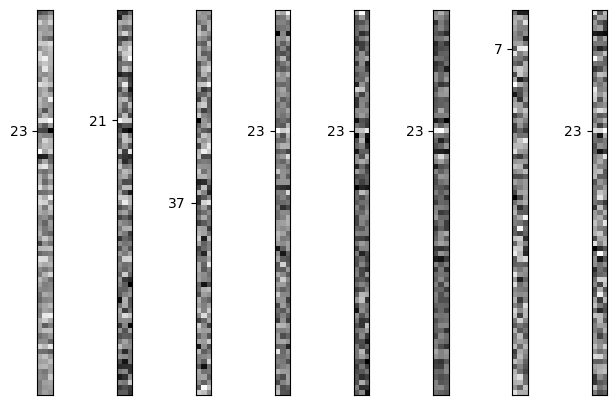

In [9]:
# visualize conv1 filters for first model iteration and indicate neurons (rows) with consistently strong weights
filters_all = np.array(filters_all)
num_filters = filters_all.shape[1]

model_iter = 0

neuron_importance_per_filter = np.mean(np.abs(filters_all[model_iter]), axis=2)  # shape (8, n_neurons)
top_neurons_per_filt = np.array([np.argmax(neuron_importance_per_filter[i]) for i in range(0, np.shape(neuron_importance_per_filter)[0])])

fig, axs = plt.subplots(1, num_filters, figsize=(num_filters * 1, 5))
for i in range(num_filters):
    axs[i].imshow(filters_all[model_iter,i, :, :], cmap='gray')
    axs[i].set_yticks([top_neurons_per_filt[i]])
    axs[i].set_xticks([])

neurons with consistently strong weights: [23 28]


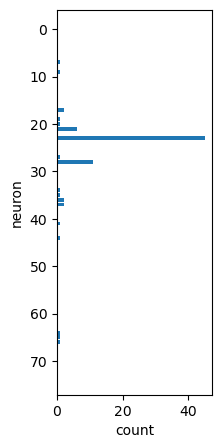

In [10]:
# find neurons that have consistently strong weights across all conv1 filters and model iterations
top_neurons_per_filt_all = []
for model_iter in range(0, model_iters):
    neuron_importance_per_filter = np.mean(np.abs(filters_all[model_iter]), axis=2)  # shape (8, n_neurons)
    
    top_neurons_per_filt = np.array([np.argmax(neuron_importance_per_filter[i]) for i in range(0, np.shape(neuron_importance_per_filter)[0])])
    top_neurons_per_filt_all.append(top_neurons_per_filt)
top_neurons_per_filt_all_concat = np.concatenate(np.array(top_neurons_per_filt_all))

plt.figure(figsize = (2,5))
counts, bins = np.histogram(top_neurons_per_filt_all_concat, bins=np.arange(0,np.shape(neuron_importance_per_filter)[1]))

plt.barh(bins[:-1], counts)
plt.xlabel('count')
plt.ylabel('neuron')
plt.gca().invert_yaxis()

#counts of neurons across filters and model iterations, take top 2
consistent_rows = np.argsort(counts)[::-1][0:2]
print('neurons with consistently strong weights: ' + str(consistent_rows))

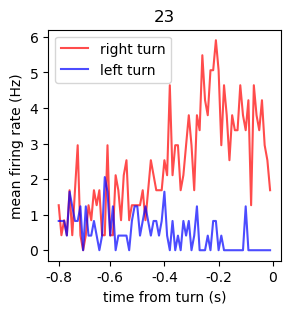

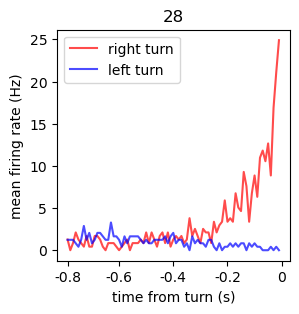

In [11]:
# examine mean firing rate for top consistent neurons between right and left turn trials
for row in consistent_rows:
    
    plt.figure(figsize = (3,3))
    plt.title(str(row), fontsize = 12)
    plt.plot(np.mean(data_tmp['right'][:,row,:], axis = 0), color = 'r', alpha = 0.7)
    plt.plot(np.mean(data_tmp['left'][:,row,:], axis = 0), color = 'b', alpha = 0.7)
    plt.ylabel('mean firing rate (Hz)')
    plt.xticks([0,19,39,59,79], labels = [-0.8, -0.6, -0.4, -0.2, 0])
    plt.xlabel('time from turn (s)')
    plt.legend(['right turn', 'left turn'])

- These SC neurons are turn-direction selective (i.e., their firing rates ramp up prior to the turn in one specific direction- left or right), so their spatio-temporal properties should be highly predictive of turn direction, good sanity check

### Run model (Hybrid CNN-FC)

In [12]:
criterion = nn.BCELoss()
epochs = 50
model_iters = 10 #(train-test splits)
loss_models = {}
test_score_models = {}

for model_to_run in ['hybrid']: #'pure', 'hybrid'
    loss_all = []
    test_scores = []

    # for nbins in np.arange(1,11): # test different time bins
    
    for nbins in [3]: # becomes stable with 3+ bins
        print('Training models with filter size ' + str(n_neurons) + 'x' + str(nbins))

        filters_all = []
        # how many iterations of the model to run
        for _ in range(0, model_iters):

            train_loader, test_loader = train_test_split(dataset)
            
            # initialize model based on type
            if model_to_run == 'pure':
                model = PureCNN(nbins=nbins)
                if use_gpu:
                    model = model.to(device)
            elif model_to_run == 'hybrid':
                model = HybridCNN(nbins=nbins)
                if use_gpu:
                    model = model.to(device)

            loss_epoch = []
            lr = 0.01

            for idx, epoch in enumerate(range(epochs)):
                if idx % 10 == 0 and idx < 30:
                    lr /= 10
                optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                loss = train(model, device, train_loader, optimizer, criterion, epoch)
                loss_epoch.append(loss)

            loss_all.append(loss_epoch)

            test_score = test(model, device, criterion, test_loader)
            test_scores.append(test_score)

            # extract filters for visualization
            filters = np.squeeze(model.conv1.weight.data.cpu().numpy())  # move to CPU and convert to numpy
            filters_all.append(filters)

    loss_models[model_to_run] = loss_all
    test_score_models[model_to_run] = test_scores

    if model_to_run == 'pure':
        print('Pure CNN Results:')
        print('Mean test accuracy:' + str(np.mean(test_score_models['pure'])))
        print('Std dev:' + str(np.std(test_score_models['pure'])))
        print('')
    elif model_to_run == 'hybrid':   
        print('Hybrid CNN+FC Results:')
        print('Mean test accuracy:' + str(np.mean(test_score_models['hybrid'])))
        print('Std dev:' + str(np.std(test_score_models['hybrid'])))
        print('')

filters_all = np.array(filters_all)

Training models with filter size 75x3
Hybrid CNN+FC Results:
Mean test accuracy:94.37499999999999
Std dev:3.8471219401290404



### Interpret filters and relate back to neural activity (Hybrid CNN-FC)

In [13]:
# find neurons in filters across all model iterations that have consistent weights across different train/test splits
filters_all = np.array(filters_all)

filters_all_abs = np.abs(filters_all)
collapsed_filters = filters_all_abs.mean(axis=2)  

# compute mean and std across filters
row_means = np.mean(collapsed_filters, axis=0)
row_stds = np.std(collapsed_filters, axis=0)

# identify rows with strong consistent weights (> mean + 1 s.d.)
threshold_mean = np.mean(row_means) + 2 * np.std(row_means)  
consistent_rows = np.where(row_means > threshold_mean)[0]

print('neurons with consistently strong weights: ' + str(consistent_rows))

neurons with consistently strong weights: [28 65]


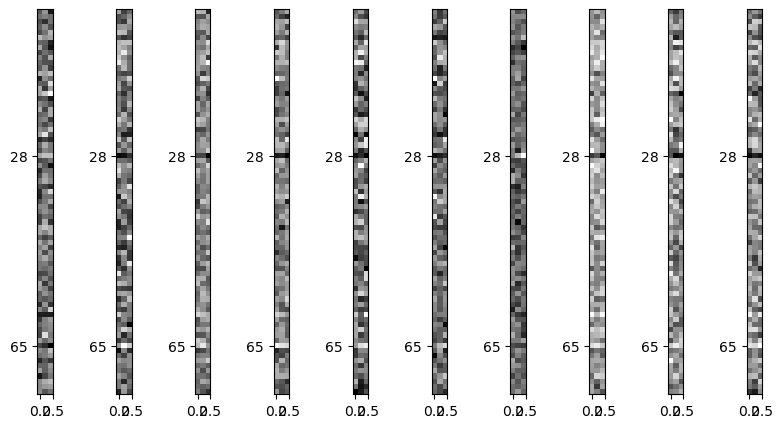

In [14]:
#visualize conv1 filters across all model iterations and indicate rows with consistently strong weights
num_filters = filters_all.shape[0]

fig, axs = plt.subplots(1, num_filters, figsize=(num_filters * 1, 5))

for i in range(num_filters):
    axs[i].imshow(filters_all[i, :, :], cmap='gray')
    axs[i].set_yticks(consistent_rows)

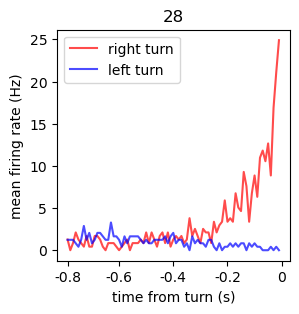

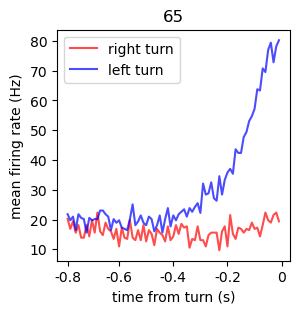

In [15]:
# examine mean firing rate for top consistent neurons between right and left turn trials
for row in consistent_rows:
    
    plt.figure(figsize = (3,3))
    plt.title(str(row), fontsize = 12)
    plt.plot(np.mean(data_tmp['right'][:,row,:], axis = 0), color = 'r', alpha = 0.7)
    plt.plot(np.mean(data_tmp['left'][:,row,:], axis = 0), color = 'b', alpha = 0.7)
    plt.ylabel('mean firing rate (Hz)')
    plt.xticks([0,19,39,59,79], labels = [-0.8, -0.6, -0.4, -0.2, 0])
    plt.xlabel('time from turn (s)')
    plt.legend(['right turn', 'left turn'])

- These SC neurons are also turn-direction selective
- Interesting that neuron 23, which got the most hits in the Pure CNN model, is not represented here 

### Conclusions

- Similar accuracy between Pure CNN and Hybrid CNN-FC model for classifying turn direction given the activity of SC neurons (> 90%) with low std
- Hybrid CNN has a slightly higher accuracy, which has been true across most if not all iterations
- There is some overlap between consistently weighted neurons, but the models pick out different combinations
- Would be intereseting to remove specific neurons, or rearrange them (for the pure CNN case) to see how this changes classification accuracy and filters